# **TAS: Tele Assistance System [DASA CASE STUDY 1]**

## **Summary**

This notebook is focused on three main objectives:
1. summarizing the key aspects of the Tele Assistance System (TAS) architecture and its adaptive capabilities in the context of telehealth services for chronic patients.
2. Modelling the TAS architecture using appropriate design notations and tools to visualize its components and interactions.
3. Simulating the TAS behavior under different scenarios to evaluate its performance and adaptability with Queue Network (QN) models.

The results will be used to evaluate the Dimensional Analysis for Software Architecture (DASA) methodology, its software tool (PyDASA) and its effectiveness in modelling and Quality Scenarios (QS) trade-off in self-adaptive-systems (SAS).

---

## **Software Architecture**
- TAS (Tele Assistance System) operates in a dynamic environment where service quality, availability, and user needs frequently change.
- The TAS is further subdivided into Controller and Target System subsystem components.
- The Controller is responsible for managing the overall system behavior, while the Target System focuses on executing specific tasks related to patient care.
- The TAS target systems follows a Service-oriented architecture (SOA) pattern.
- The TAS Controller follows a MAPE-K (Monitor-Analyze-Plan-Execute-Knowledge) feedback loop for self-adaptation.
- Adaptations focus on maintaining **reliability**, **performance**, and **compliance** with patient care standards (5 specific scenarios).
- ActivFORMS provides the runtime framework for model-based adaptation using runtime models, simulations, and verified decision-making.

## **Project Overview**

TAS (Tele Assistance System) is a software solution for remote monitoring and telehealth services in chronic ill patients (e.g.: diabetes).

As seen in the [Context Diagram](#Context-Diagram) shows how patients with chronic conditions (such as diabetes) interact with the system using wearable monitoring devices that collect vital signs. These measurements are transmitted to TAS, which processes and analyzes the data using third-party Medical Analysis Services (MAS). Based on analysis results, TAS can trigger appropriate responses - either sending medication adjustments via Drug Services (DS) for non-critical situations or dispatching emergency assistance through Alarm Services (AS) when critical conditions are detected.


The TAS (Tele Assistance System) context diagram illustrates how the system operates within its broader healthcare ecosystem. At the center is the TAS core, which connects patients at home to various healthcare services through a self-adaptive architecture. 


The diagram notes highlights the system's self-adaptive capabilities through the MAPE-K (Monitor-Analyze-Plan-Execute plus Knowledge) feedback loop, which continuously evaluates service quality and performance. This allows TAS to dynamically reconfigure itself by switching between alternative service providers when failures or delays occur, ensuring reliable telehealth support even in uncertain conditions.

The diagram notes highlights the system's main quality concerns:
1. Improving service reliability
2. Enhancing response time
3. Reducing costs

This concerns translates to five possible adaptation scenarios:
1. Replace underperforming service instances with backup alternatives.
2. Switch to a service instance with better response times.
3. Introduce a new service in the workflow.
4. Update the healthcare workflow with new specifications.
5. Change the healthcare workflow if errors are detected.

These adaptation capabilities are specifically **self-optimization** and **self-healing** and focus on the _Quality Attribute_ (_QA_) trade-off between **reliability** and **performance**, and **cost**. All this allows TAS to dynamically reconfigure itself by switching between alternative service providers when failures or delays occur, ensuring reliable telehealth support even in uncertain conditions. 

### **Context Diagram**

<!-- <svg viewBox="0 0 2000 1430" width="980" height="650"> -->
<svg viewBox="0 0 2000 1430" width="980" height="650">
    <!-- SVG content -->
    <image href="assets/cs1/img/01 - Context.svg" alt="context-diagram" />
    <div align="center"><em>Image 1. Reconstructed TAS Context Diagram.</em></div>
</svg>

---

## **Subsystem Decomposition**

Dividing TAS into Target and Controller Parts (MAPE-K Structure)

| Subsystem | Comps |
|:---|:---|
| **Target System (Managed System)** | - **TAS Core Services:** Vital Parameters Monitor, Medication Management, Emergency Response Trigger <br> - **Service Integrations:** Medical Analysis Services (MAS), Alarm Services (AS), Drug Services (DS) from third-party providers <br> - **Probes:** Instruments to collect data about vital signs, service invocations, failures, and latencies <br> - **Effectors:** Mechanisms to replace or reconfigure services dynamically |
| **Controller (Managing System)** | - **Monitor:** Observes system state, updates runtime models (service failures, delays, costs) <br> - **Analyzer:** Runs simulations (runtime statistical model checking) on updated models to predict system qualities <br> - **Planner:** Selects best service configuration based on goals (availability, performance, cost) <br> - **Executor:** Applies adaptations (switches services, reconfigures workflows) <br> - **Knowledge Base:** Maintains models of the system, environment models, adaptation goals, quality models |
<div align="center"><em>Table 1: Subsystem Decomposition based on the MAPE-K loop and ActivFORMS architecture.</em></div>

### **Target System Architecture**

#### **Service Diagram**

The TAS [Service Catalogue](#Service-Diagram) diagram provides a comprehensive overview of the system's SOA architecture and integration points. At its core, TAS offers three primary service areas. One, **vital parameters monitoring** for collecting patient health data. Two, **assistance workflow** for monitoring patient's illness and coordinating external services. And three, **third-party providers** with capabilities divided into three categories: _Medical Analysis_ for health data processing, _Alarms_ for emergency notifications, and _Medication_ for drug management.

The core services interact with the third-party providers in response to patient medication needs such as tracking and adjusting medication regimens, or in emergency response by triggering alerts for critical situations. The diagram illustrates how TAS implements service redundancy the _Medication Analysis_ and _Alarms_ categories with multiple instances of Medical Analysis Services (MAS) and Alarm Services (AS) for each providers. this allows to dynamically select services based on availability, performance, and cost metrics of each provide. This service-oriented architecture enables the system to maintain continuous operation even when individual services fail, by switching to alternative providers while maintaining consistent interfaces and functionality.

<svg viewBox="0 0 3800 1000" width="1400" height="600">
    <!-- SVG content -->
    <image href="assets/cs1/img/02 - Services.svg" alt="service-diagram" />
    <div align="center"><em>Image 2. TAS Service Catalogue Diagram.</em></div>
</svg>

#### **Workflow Diagram**

The TAS [Sequence Diagram](#Workflow-Diagram) illustrates the interaction flow between patients, core TAS components, and third-party services during healthcare monitoring and response. The sequence begins with patient vital signs being collected through wearable devices, which are then processed by the TAS Core. When abnormal readings are detected, the system engages Medical Analysis Services (MAS) to evaluate patient data. Based on analysis results, the system follows one of three paths: for normal conditions, it continues monitoring; for non-critical issues, it coordinates with Drug Services (DS) to adjust medication; and for emergencies, it triggers Alarm Services (AS) to alert healthcare providers. Throughout this sequence, the MAPE-K feedback loop continuously monitors service quality and execution, enabling dynamic service substitution when performance degrades or failures occur.

<svg viewBox="0 0 3200 1700" width="1200" height="600">
    <!-- SVG content -->
    <image href="assets/cs1/img/03 - Workflow.svg" alt="workflow-diagram" />
    <div align="center"><em>Image 3. TAS Target System Sequence Diagram.</em></div>
</svg>

#### **Functional Requirements (Reported Capabilities)**

| ID | Description |
|:-----|:---|
| RC-001 | Provide remote health support for patients with chronic conditions within their homes. |
| RC-002 | Periodically measure patients' vital signs using wearable devices and sensors. |
| RC-003 | Analyze patient data using third-party medical analysis services to assess health status. |
| RC-004 | Invoke pharmacy services to deliver medication if analysis indicates a treatment change is needed. |
| RC-005 | Adjust medication dosage dynamically based on updated health analysis. |
| RC-006 | Send automatic alarms and alerts to emergency services during critical situations. |
| RC-007 | Dynamically integrate new third-party services into existing workflows to enhance system functionality. |
| RC-008 | Adapt to changing healthcare goals by modifying workflows and service selections in real-time. |
| RC-009 | Ensure system reliability by switching to equivalent services when current ones fail or degrade. |
| RC-010 | Continuously monitor service performance and adjust workflows to optimize reliability, performance, and cost. |
<div align="center"><em>Table 2. TAS reported Functional Requirements.</em></div>

#### **Quality Scenarios (QS)**

| ID | Quality Attribute | Sub-Category | Scenario Description |
|:-----|:---|:---|:---|
| QS-001 | Availability | Fault Tolerance | TAS must detect third-party service failures and switch to a backup service within 30 seconds. |
| QS-002 | Performance | Response Time | TAS must process health analysis results and issue alerts within 2.5 seconds. |
| QS-003 | Interoperability | Syntactic/Semantic | TAS must successfully integrate new third-party services dynamically without downtime. |
| QS-004 | Adaptability | Dynamic Reconfiguration | TAS must reconfigure workflows dynamically based on real-time patient data and healthcare goals. |
<div align="center"><em>Table 3. TAS reported Quality Scenarios.</em></div>

---

### **Controller Architecture**

<!-- TODO: Describe the controller architecture, including components, interactions, and data flow. -->

### **Adaptation Scenarios (AS)**

| ID | Scenario | Description | Adaptation Strategy |
|:-------|:---|:---|:---|
| AS-001 | Service Failure | A third-party service fails to respond, impacting TAS operations. | Switch to an equivalent service; use redundancy (invoke multiple services simultaneously if needed). |
| AS-002 | Variation in Service Response Time | A third-party service exceeds expected response times, degrading TAS performance. | Switch to a more performant service; prioritize services based on real-time response metrics. |
| AS-003 | New Service Introduction | A new third-party service becomes available. | Dynamically recognize and integrate new services into the registry and workflows. |
| AS-004 | Changing Goals | Healthcare objectives or patient needs change over time. | Adjust workflows and select appropriate services to meet updated goals. |
| AS-005 | Wrong Operation Sequence | Errors or inefficiencies in workflow execution. | Redesign and reconfigure the workflow sequence to ensure compliance with functional requirements. |

---

## **References & Sources**
<!-- TODO fix the references, links and details -->
1. [Queueing Theory](https://en.wikipedia.org/wiki/Queueing_theory)
2. [Dimensional Analysis](https://en.wikipedia.org/wiki/Dimensional_analysis)
3. [Simulation in Healthcare](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6466220/)

---

# **QN Code**

_**SUMMARY:**_

This code is divided into two main parts:
1. The Analytical Queue Network model.
2. The Stochastic Process model (Queue Network Simulation).

Both models are implemented in the following sections, Comments are added as needed to explain the code.

### **Necessary Imports**

In [1]:
# -*- coding: utf-8 -*-
# Native imports
import os
import re
import sys
import time

# Third-party imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# for plotting refined dimensionless chart
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import binned_statistic_2d
import matplotlib.ticker as ticker

# package import PyDASA
# config module
from pydasa.utils import config
# FDU modules
from pydasa.core.fundamental import Dimension
# FDU regex management
from pydasa.dimensional.framework import DimScheme
# Variable and Variable modules
from pydasa.core.parameter import Variable
# Dimensional Matrix Modelling module
from pydasa.dimensional.model import DimMatrix
# sensitivity analysis modules
from pydasa.analysis.scenario import DimSensitivity
from pydasa.handlers.influence import SensitivityHandler
# Monte Carlo Simulation modules
from pydasa.analysis.simulation import MonteCarloSim
from pydasa.handlers.practical import MonteCarloHandler

### **Queueing Model**

#### **FDU (Fundamental Design Unit)**

In [2]:
# setting up custom FDU for software architecture
tas_fwk = "SOFTWARE"
tas_scm = DimScheme(_sym="FDU_{TAS}",
                        _alias="fdu_tas",
                        _idx=0,
                        name="TAS FDUs",
                        _fwk=tas_fwk,
                        description="FDU schema for the TAS case study.")
# print(tas_scm)
print("=== TAS Fundamental Dimenional Unit (FDU) Schema ===")
for dim in tas_scm.fdus:
    print(f"\t'{dim.sym}': {dim.name}, [{dim.unit}]")

=== TAS Fundamental Dimenional Unit (FDU) Schema ===
	'T': Time, [s]
	'D': Data, [bit]
	'E': Effort, [req]
	'C': Connectivity, [node]
	'A': Capacity, [process]


In [3]:
tas_scm.update_global_config()
print("\n==== Checking Schema Regex ====")
print("\tWKNG_DFLT_FDU_PREC_LT:", config.WKNG_FDU_PREC_LT)
print("\tWKNG_FDU_RE:", config.WKNG_FDU_RE)
print("\tWKNG_POW_RE:", config.WKNG_POW_RE)
print("\tWKNG_NO_POW_RE:", config.WKNG_NO_POW_RE)
print("\tWKNG_FDU_SYM_RE:", config.WKNG_FDU_SYM_RE)


==== Checking Schema Regex ====
	WKNG_DFLT_FDU_PREC_LT: ['T', 'D', 'E', 'C', 'A']
	WKNG_FDU_RE: ^[TDECA](\^-?\d+)?(\*[TDECA](?:\^-?\d+)?)*$
	WKNG_POW_RE: \-?\d+
	WKNG_NO_POW_RE: [TDECA](?!\^)
	WKNG_FDU_SYM_RE: [TDECA]


#### **Dimensional Variables**

Based on the QN (Queue Network) model for the component + sequenece diagrams

<!-- ![Diagram description](./images/diagram.svg) -->
<img src="./assets/img/CS-01-Health TAS/04A - Queue Network.svg"  width="1200" alt="TAS queue network component diagram" style="display: block; margin: auto;">
<!-- <img src="./images/tas_architecture.svg" width="800" alt="TAS queue network component diagram" style="display: block; margin: auto;"> -->


In [4]:
# list of variables
# all components use the queue model M/M/1/K
# arrival rate => lambda, IN, independent
# departure rate => chi/x, IN, dependent
# service rate => miu, IN, independent
# request in queue => n, CTRL ~ < 60%*K
# requests in service/servers => c, IN
# mean service time => S, OUT, dependant
# mean queue time => Q, OUT, dependant
# mean response time => W = Q + S, OUT, independent
# mean queue size => L = λ * W, OUT, dependant
# max queue size => K, independent

print("\n==== Variables ====")
# dict with variables
tas_vars ={
    # C1 -> TAS (Tele Assistance Service) 1
    # C1 = C2 = C3 = C10 = C12 = C13
    # C1 = TAS_1
    # λ1=344.83 [req/s], Χ1=344.83 [req/s], μ1=1000.00 [req/s]
    "\\lambda_{1}": Variable(_sym="\\lambda_{1}",
                                   _alias="lambda_tas_1",
                                   _fwk="SOFTWARE",
                                   name="TAS component 1 arrival 1",
                                   description="TAS arrival rate 1",
                                   relevant=True,
                                   _idx=0,
                                   _cat="IN",
                                   _units="req/s",
                                   _dims="E*T^-1",
                                   _min=0.0,
                                   _max=344.83,
                                   _mean=344.83,
                                   _std_units="req/s",
                                   _std_min=0.0,
                                   _std_max=344.83,
                                   _std_mean=344.83,
                                   _dist_type="exponential",
                                   _dist_params={"scale": 1/344.83},
                                   _dist_func=lambda: np.random.exponential(1/344.83)),
    "\\miu_{1}": Variable(_sym="\\miu_{1}",
                                   _alias="miu_tas_1",
                                   _fwk="SOFTWARE",
                                   name="TAS component 1 service rate",
                                   description="TAS service rate 1",
                                   relevant=True,
                                   _idx=1,
                                _cat="CTRL",
                                   _units="req/s",
                                   _dims="E*T^-1",
                                   _min=0.0,
                                   _max=1000.0,
                                   _mean=1000.0,
                                   _std_units="req/s",
                                   _std_min=0.0,
                                   _std_max=1000.0,
                                   _std_mean=1000.0,
                                   _dist_type="exponential",
                                   _dist_params={"scale": 1/1000},
                                   _dist_func=lambda: np.random.exponential(1/1000)),
    "K_{1}": Variable(_sym="K_{1}",
                             _alias="k_1",
                             _fwk="SOFTWARE",
                             name="TAS component 1 max queue size",
                             description="TAS max queue size 1",
                             relevant=True,
                             _idx=3,
                             _cat="IN",
                             _units="req",
                             _dims="E",
                             _min=99.9,
                             _max=100.1,
                             _mean=100.0,
                             _std_units="req",
                             _std_min=99.9,
                             _std_max=100.1,
                             _std_mean=100.0,
                             _dist_type="uniform",
                             _dist_params={"constant": 100},
                             _dist_func=lambda: 100),
    "n_{1}": Variable(_sym="n_{1}",
                             _alias="n_1",
                             _fwk="SOFTWARE",
                             name="TAS component 1 requests in queue",
                             description="TAS requests in queue 1",
                             relevant=True,
                             _idx=2,
                             _cat="IN",
                             _units="req",
                             _dims="E",
                             _min=0.0,
                             _max=60.0,
                             _mean=30.0,
                             _std_units="req",
                             _std_min=0.0,
                             _std_max=60.0,
                             _std_mean=30.0,
                             _dist_type="uniform",
                             _dist_params={"low": 0, "high": 60},
                             _dist_func=lambda: np.random.uniform(0, 60)),
    "W_{1}": Variable(_sym="W_{1}",
                             _alias="w_1",
                             _fwk="SOFTWARE",
                             name="TAS component 1 response time",
                             description="TAS response time 1",
                             relevant=True,
                             _idx=4,
                             _cat="OUT",
                             _units="s/req",
                             _dims="T*E^-1",
                             _min=0.0,
                             _max=60.0,
                             _mean=30.0,
                             _std_units="s/req",
                             _std_min=0.0,
                             _std_max=60.0,
                             _std_mean=30.0,
                             _dist_type="uniform",
                             _dist_params={"low": 0, "high": 60},
                             _dist_func=lambda: np.random.uniform(0, 60)),
    "L_{1}": Variable(_sym="L_{1}",
                             _alias="l_1",
                             _fwk="SOFTWARE",
                             name="TAS component 1 latency",
                             description="TAS latency 1",
                             relevant=True,
                             _idx=5,
                            _cat="CTRL",
                             _units="req",
                             _dims="E",
                             _min=0.0,
                             _max=60.0,
                             _mean=30.0,
                             _std_units="req",
                             _std_min=0.0,
                             _std_max=60.0,
                             _std_mean=30.0,
                             _dist_type="uniform",
                             _dist_params={"low": 0, "high": 60},
                             _dist_func=lambda: np.random.uniform(0, 60)),
    # # C2 = TAS_2
    # # λ2=258.62 [req/s], Χ2=258.62 [req/s], μ2=1000.00 [req/s]
    # "C_{TAS_{2}}": Variable(),
    # # C3 = TAS_3
    # # λ3=174.14 [req/s], Χ3=174.14 [req/s], μ3=1000.00 [req/s]
    # "C_{TAS_{3}}": Variable(),
    # # C4, C5, C6 -> MAS (Medical Assistance Service)
    # # C4 = MAS_1
    # # λ4=88.17 [req/s], Χ4=77.59 [req/s], μ4=180.00 [req/s]
    # "C_{MAS_{1}}": Variable(),
    # # C5 = MAS_2
    # # λ5=132.09 [req/s], Χ5=122.84 [req/s], μ5=530.00 [req/s]
    # "C_{MAS_{2}}": Variable(),
    # # C6 = MAS_3
    # # λ6=70.96 [req/s], Χ6=58.19 [req/s], μ6=150.00 [req/s]
    # "C_{MAS_{3}}": Variable(),
    # # C7, C8, C9 -> AS (Alarm Service)
    # # C7 = AS_1
    # # λ7=65.22 [req/s], Χ7=58.05 [req/s], μ7=700.00 [req/s]
    # "C_{AS_{1}}": Variable(),
    # # C8 = AS_2
    # # λ8=60.46 [req/s], Χ8=58.05 [req/s], μ8=410.00 [req/s]
    # "C_{AS_{2}}": Variable(),
    # # C9 = AS_3
    # # λ9=70.79 [req/s], Χ9=58.05 [req/s], μ9=1580.00 [req/s]
    # "C_{AS_{3}}": Variable(),
    # # C10 = TAS_4
    # # λ10=60.46 [req/s], Χ10=58.05 [req/s], μ10=410.00 [req/s]
    # "C_{TAS_{4}}": Variable(),
    # # C11 -> DS (Drug Service)
    # # C11 = DS_1
    # # λ11=179.67 [req/s], Χ11=183.62 [req/s], μ11=550.00 [req/s]
    # "C_{DS_{1}}": Variable(),
    # # C12 = TAS_5
    # # λ12=174.14 [req/s], Χ12=174.14 [req/s], μ12=1000.00 [req/s]
    # "C_{TAS_{5}}": Variable(),
    # # C13 = TAS_6
    # # λ13=170.69 [req/s], Χ13=174.44 [req/s], μ13=1000.00 [req/s]
    # "C_{TAS_{6}}": Variable(),
}





"""
C Vs. Metric	λi [req/s]	Χi [req/s]	μi [req/s]
*C1	                344.83	344.83	1000.00
*C2	                258.62	258.62	1000.00
*C3	                174.14	174.14	1000.00
C4	                88.17	77.59	180.00
C5	                132.09	122.84	530.00
C6	                70.96	58.19	150.00
C7	                65.22	58.05	700.00
C8	                60.46	58.05	410.00
C9	                70.79	58.05	1580.00
*C10	            258.62	258.62	1000.00
C11	                179.67	183.62	550.00
*C12	            174.14	174.14	1000.00
*C13	            170.69	174.44	1000.00
Sum	                157.57	153.94	776.92

Avg for all C1-C13	λi [req/s]	Χi [req/s]	μi [req/s]
f(M/M/1/∞/FIFO)	f(M/M/1/∞/FIFO)
Li [req]	Wi [s*req^(-1)]
2.333E+00	2.020E-02


"""


for i, var in enumerate(tas_vars.values()):
    var.idx = i
    print(f"Variable {var.idx}: '{var.sym}', ({var.cat})")
    print(f"\tStd Units: '{var.std_units}'")
    print(f"\tDimensionality: '{var.dims}'")



==== Variables ====
Variable 0: '\lambda_{1}', (IN)
	Std Units: 'req/s'
	Dimensionality: 'E*T^-1'
Variable 1: '\miu_{1}', (CTRL)
	Std Units: 'req/s'
	Dimensionality: 'E*T^-1'
Variable 2: 'K_{1}', (IN)
	Std Units: 'req'
	Dimensionality: 'E'
Variable 3: 'n_{1}', (IN)
	Std Units: 'req'
	Dimensionality: 'E'
Variable 4: 'W_{1}', (OUT)
	Std Units: 's/req'
	Dimensionality: 'T*E^-1'
Variable 5: 'L_{1}', (CTRL)
	Std Units: 'req'
	Dimensionality: 'E'


#### **Dimensionl Model**

In [5]:
tas_model = DimMatrix(_fwk="SOFTWARE",
                    _idx=0,
                    _framework=tas_scm)
tas_model.variables = tas_vars
print("Setting parameters for the dimensional analysis")
print(len(tas_model.variables), tas_model.variables.keys(), "\n")

tas_model.relevant_lt = tas_vars
print("Setting the relevance list for dimensional analysis")
print(len(tas_model.relevant_lt), tas_model.relevant_lt.keys(), "\n")

# print(tas_model, "\n")
# print(tas_model.working_fdus, "\n")

Setting parameters for the dimensional analysis
6 dict_keys(['\\lambda_{1}', '\\miu_{1}', 'K_{1}', 'n_{1}', 'W_{1}', 'L_{1}']) 

Setting the relevance list for dimensional analysis
6 dict_keys(['\\lambda_{1}', 'K_{1}', 'n_{1}', 'W_{1}', '\\miu_{1}', 'L_{1}']) 



In [6]:
# solving dimensional problem
tas_model.create_matrix()
tas_model.solve_matrix()

print(tas_model._pivot_cols, "\n")
print(tas_model, "\n")

[0, 1] 

DimMatrix(sym='', alias='', fwk='SOFTWARE', idx=0, name='Dimensional Matrix', description='', framework=DimScheme(_sym='FDU_{TAS}', _alias='fdu_tas', _fwk='SOFTWARE', _idx=0, name='TAS FDUs', description='Fdu schema for the tas case study.', _fdus=[Dimension(_sym='T', _alias='', _fwk='SOFTWARE', _idx=0, name='Time', description='Duration of an event or interval.', _unit='s'), Dimension(_sym='D', _alias='', _fwk='SOFTWARE', _idx=1, name='Data', description='Information processed by a system.', _unit='bit'), Dimension(_sym='E', _alias='', _fwk='SOFTWARE', _idx=2, name='Effort', description='Measure of computational effort/complexity.', _unit='req'), Dimension(_sym='C', _alias='', _fwk='SOFTWARE', _idx=3, name='Connectivity', description='Measure of interconnections between components.', _unit='node'), Dimension(_sym='A', _alias='', _fwk='SOFTWARE', _idx=4, name='Capacity', description='Maximum amount of data that can be stored/processed.', _unit='process')], _fdu_map={'T': Dimen

#### **Dimensionless Coefficients**

In [7]:
for k, v in tas_model.coefficients.items():
    pi = v
    print(f"Coefficient: {k} = {pi._pi_expr}")

Coefficient: \Pi_{0} = \frac{n_{1}}{K_{1}}
Coefficient: \Pi_{1} = \lambda_{1}*W_{1}
Coefficient: \Pi_{2} = \frac{\miu_{1}}{\lambda_{1}}
Coefficient: \Pi_{3} = \frac{L_{1}}{K_{1}}


#### **Sensitivity Analysis**

In [8]:
tas_sena = SensitivityHandler(_idx=0,
                              _sym="SA_{TAS_{0}}",
                              _fwk="SOFTWARE",
                              name="Sensitivity Analysis TAS No 1",
                              description="Sensitivity Analysis for TAS 1",
                              _variables=tas_vars,
                              _coefficients=tas_model._coefficients,)

In [9]:
for k, v in tas_sena.coefficients.items():
    pi = v
    print(f"Coefficient: {k} = {pi._pi_expr}")

Coefficient: \Pi_{0} = \frac{n_{1}}{K_{1}}
Coefficient: \Pi_{1} = \lambda_{1}*W_{1}
Coefficient: \Pi_{2} = \frac{\miu_{1}}{\lambda_{1}}
Coefficient: \Pi_{3} = \frac{L_{1}}{K_{1}}


In [10]:
print("=== Sym Analysis: ===")
tas_sena.analyze_symbolic(val_type="mean")

for k, v in tas_sena.results.items():
    print(f"{k}: {v}")
# print(tas_sena.results, "\n")

print("\n=== Num Analysis: ===")
tas_sena.analyze_numeric(n_samples=50000)

for k, v in tas_sena.results.items():
    print(f"{k}: {v}")
    for a, b in v.items():
        print(f"\t{a}: {b}")

print("Sensitivity Analysis Results:")
# print(tas_sena.analyses, "\n")

for key, val in tas_sena.results.items():
    txt = f"{key}: {val}"
    print(txt)

=== Sym Analysis: ===


SEN_{\Pi_{0}}: {'K_{1}': -0.003, 'n_{1}': 0.01}
SEN_{\Pi_{1}}: {'W_{1}': 344.83, '\\lambda_{1}': 30.0}
SEN_{\Pi_{2}}: {'\\lambda_{1}': -0.008409882261236259, '\\miu_{1}': 0.0028999797001420993}
SEN_{\Pi_{3}}: {'K_{1}': -0.003, 'L_{1}': 0.01}

=== Num Analysis: ===
SEN_{\Pi_{0}}: {'S1': [np.float64(0.001585918809184547), np.float64(8.077585812533836e-05)], 'ST': [np.float64(0.8751977650560765), np.float64(0.504815741060658)], 'S1_conf': [np.float64(0.00020661322475865228), np.float64(0.00030114918439902476)], 'ST_conf': [np.float64(0.0031924966532619445), np.float64(0.003163360582373772)], 'names': ['K_{1}', 'n_{1}']}
	S1: [np.float64(0.001585918809184547), np.float64(8.077585812533836e-05)]
	ST: [np.float64(0.8751977650560765), np.float64(0.504815741060658)]
	S1_conf: [np.float64(0.00020661322475865228), np.float64(0.00030114918439902476)]
	ST_conf: [np.float64(0.0031924966532619445), np.float64(0.003163360582373772)]
	names: ['K_{1}', 'n_{1}']
SEN_{\Pi_{1}}: {'S1': [np.float64(0.42763

#### **Monte Carlo Simulation**

In [11]:
print("\n=== monte carlo handler ===")
# Create a handler
tas_mch = MonteCarloHandler(_sym="MCH_{0}",
                            _fwk="SOFTWARE",
                            name="TAS Monte Carlo Handler",
                            description="TAS Monte Carlo Handler for simulations",
                            _variables=tas_model.relevant_lt,
                            _coefficients=tas_model.coefficients)
print(tas_mch, "\n")


=== monte carlo handler ===
MonteCarloHandler(sym='MCH_{0}', alias='MCH_0', fwk='SOFTWARE', idx=-1, name='TAS Monte Carlo Handler', description='Tas monte carlo handler for simulations', cat='NUM', variables={'\\lambda_{1}': Variable(_sym='\\lambda_{1}', _alias='lambda_tas_1', _fwk='SOFTWARE', _idx=0, name='TAS component 1 arrival 1', description='Tas arrival rate 1', _cat='IN', _dims='E*T^-1', _units='req/s', _std_dims='T^(-1)*E^(1)', _sym_exp='T**(-1)* E**(1)', _dim_col=[-1, 0, 1, 0, 0], _min=0.0, _max=344.83, _mean=344.83, _dev=None, _std_units='req/s', _std_min=0.0, _std_max=344.83, _std_mean=344.83, _std_dev=None, _step=None, _std_range=array([], dtype=float64), _dist_type='exponential', _dist_params={'scale': 0.0028999797001420993}, _dist_func=<function <lambda> at 0x0000021138CFB9A0>, relevant=True), 'K_{1}': Variable(_sym='K_{1}', _alias='k_1', _fwk='SOFTWARE', _idx=1, name='TAS component 1 max queue size', description='Tas max queue size 1', _cat='IN', _dims='E', _units='req'

In [12]:
tas_mch._create_distributions()
print(tas_mch._distributions)
tas_mch._create_simulations()
print(tas_mch._simulations.keys())
for k, v in tas_mch._simulations.items():
    print(f"Simulation dist = {k}:\n\t{v._distributions}")
tas_mch.simulate(n_samples=50000)

{'\\lambda_{1}': {'dtype': 'exponential', 'params': {'scale': 0.0028999797001420993}, 'func': <function <lambda> at 0x0000021138CFB9A0>}, 'K_{1}': {'dtype': 'uniform', 'params': {'constant': 100}, 'func': <function <lambda> at 0x0000021138CFBC70>}, 'n_{1}': {'dtype': 'uniform', 'params': {'low': 0, 'high': 60}, 'func': <function <lambda> at 0x0000021138CFBD00>}, 'W_{1}': {'dtype': 'uniform', 'params': {'low': 0, 'high': 60}, 'func': <function <lambda> at 0x0000021138CFBD90>}, '\\miu_{1}': {'dtype': 'exponential', 'params': {'scale': 0.001}, 'func': <function <lambda> at 0x0000021138CFBBE0>}, 'L_{1}': {'dtype': 'uniform', 'params': {'low': 0, 'high': 60}, 'func': <function <lambda> at 0x0000021138CFBE20>}}
dict_keys(['\\Pi_{0}', '\\Pi_{1}', '\\Pi_{2}', '\\Pi_{3}'])
Simulation dist = \Pi_{0}:
	{'K_{1}': {'dtype': 'uniform', 'params': {'constant': 100}, 'func': <function <lambda> at 0x0000021138CFBC70>}, 'n_{1}': {'dtype': 'uniform', 'params': {'low': 0, 'high': 60}, 'func': <function <la

In [13]:
print("=== Monte Carlo Simulation Report ===")
for pi, results in tas_mch._results.items():
    for k, v in results.items():
        if k == "statistics":
            coef = tas_mch._coefficients[pi].pi_expr
            print(f"\nCoefficient: {pi} = {coef}")
            # print(f"Result for {k}: {v}")
            stats = v
            for a, b in stats.items():
                print(f"\t{a}: {b}")
        # else:
        #     print(f"Other result for {k}: {v.shape}")

=== Monte Carlo Simulation Report ===

Coefficient: \Pi_{0} = \frac{n_{1}}{K_{1}}
	mean: 20.822195583542726
	median: 3.338971226227759
	std_dev: 677.4505256097566
	variance: 458939.2146489354
	min: 1.6667004016233857
	max: 127806.74779042482
	count: 50000

Coefficient: \Pi_{1} = \lambda_{1}*W_{1}
	mean: 0.0873807042003233
	median: 0.04649776983252915
	std_dev: 0.11396088300127734
	variance: 0.012987082854430822
	min: 1.1437489513484725e-07
	max: 1.4465869044699513
	count: 50000

Coefficient: \Pi_{2} = \frac{\miu_{1}}{\lambda_{1}}
	mean: 30.38204775715988
	median: 2.9243997752061652
	std_dev: 662.1144082508957
	variance: 438395.4896134338
	min: 1.8021470765026092e-05
	max: 104575.70299114486
	count: 50000

Coefficient: \Pi_{3} = \frac{L_{1}}{K_{1}}
	mean: 20.004603850363146
	median: 3.353499073994144
	std_dev: 757.918882275011
	variance: 574441.032109002
	min: 1.6667299266845796
	max: 147901.63546922576
	count: 50000


#### **Data Analysis**

The steps are:

1) Extract and organize simulation data into a DataFrame.
2) Add metadata and basic statistics.
3) Save the dataframe to a CSV file.
4) Create a basic dimensionless plot (similar to Moody's chart)

In [14]:
# exporing to dataframe to process
print("=== Data Analysis ===")
# Create a dictionary to store all the results
all_results = {}

# Extract results for each coefficient
for coef in tas_mch.coefficients:
    simul = tas_mch.simulations[coef]
    results = simul.export_results()
    all_results.update(results)

=== Data Analysis ===


In [15]:
for k, v in all_results.items():
    print(f"{k}: {type(v)}, {v.shape}")

n_{1}_\Pi_{0}: <class 'numpy.ndarray'>, (50000,)
K_{1}_\Pi_{0}: <class 'numpy.ndarray'>, (50000,)
\Pi_{0}: <class 'numpy.ndarray'>, (50000,)
\lambda_{1}_\Pi_{1}: <class 'numpy.ndarray'>, (50000,)
W_{1}_\Pi_{1}: <class 'numpy.ndarray'>, (50000,)
\Pi_{1}: <class 'numpy.ndarray'>, (50000,)
\miu_{1}_\Pi_{2}: <class 'numpy.ndarray'>, (50000,)
\lambda_{1}_\Pi_{2}: <class 'numpy.ndarray'>, (50000,)
\Pi_{2}: <class 'numpy.ndarray'>, (50000,)
L_{1}_\Pi_{3}: <class 'numpy.ndarray'>, (50000,)
K_{1}_\Pi_{3}: <class 'numpy.ndarray'>, (50000,)
\Pi_{3}: <class 'numpy.ndarray'>, (50000,)


In [16]:
# Create a master dataframe
df_results = pd.DataFrame(all_results)

# Show the first few rows
print(df_results.head())

   n_{1}_\Pi_{0}  K_{1}_\Pi_{0}    \Pi_{0}  \lambda_{1}_\Pi_{1}  \
0      38.488970          100.0   2.598147             0.001835   
1      13.904355          100.0   7.191991             0.000009   
2      10.082400          100.0   9.918273             0.001651   
3       1.200549          100.0  83.295244             0.002283   
4       2.097532          100.0  47.675073             0.001371   

   W_{1}_\Pi_{1}   \Pi_{1}  \miu_{1}_\Pi_{2}  \lambda_{1}_\Pi_{2}   \Pi_{2}  \
0       4.600234  0.008442          0.001665             0.001265  0.759655   
1      30.684747  0.000278          0.001147             0.000630  0.549593   
2       3.659827  0.006043          0.002570             0.003770  1.466971   
3      14.867125  0.033935          0.000911             0.000895  0.982136   
4      36.117072  0.049515          0.001443             0.007269  5.038685   

   L_{1}_\Pi_{3}  K_{1}_\Pi_{3}    \Pi_{3}  
0       1.301893          100.0  76.811246  
1      36.647828          100.0 

In [17]:
# Add basic statistics as columns
for pi in tas_mch._coefficients.keys():
    stats = tas_mch._results[pi]["statistics"]
    # Calculate normalized values (value/mean)
    df_results[f"{pi}_normalized"] = df_results[pi] / stats["mean"]

# Print dataframe info
print(df_results.info())
print("\nSummary statistics:")
print(df_results.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   n_{1}_\Pi_{0}        50000 non-null  float64
 1   K_{1}_\Pi_{0}        50000 non-null  float64
 2   \Pi_{0}              50000 non-null  float64
 3   \lambda_{1}_\Pi_{1}  50000 non-null  float64
 4   W_{1}_\Pi_{1}        50000 non-null  float64
 5   \Pi_{1}              50000 non-null  float64
 6   \miu_{1}_\Pi_{2}     50000 non-null  float64
 7   \lambda_{1}_\Pi_{2}  50000 non-null  float64
 8   \Pi_{2}              50000 non-null  float64
 9   L_{1}_\Pi_{3}        50000 non-null  float64
 10  K_{1}_\Pi_{3}        50000 non-null  float64
 11  \Pi_{3}              50000 non-null  float64
 12  \Pi_{0}_normalized   50000 non-null  float64
 13  \Pi_{1}_normalized   50000 non-null  float64
 14  \Pi_{2}_normalized   50000 non-null  float64
 15  \Pi_{3}_normalized   50000 non-null 

In [18]:
# # Save the dataframe to a CSV file
# output_path = "results/cs1/csv/tas_simulation_results.csv"
# df_results.to_csv(output_path, index=False)
# print(f"\nResults saved to {output_path}")

In [19]:
# Set global style for all plots - white background with black font
plt.style.use('default')  # Reset to default style first
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'lightgray',
    'font.size': 10,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

# Set seaborn style
sns.set_style("whitegrid", {'axes.edgecolor': 'black',
                            'grid.color': 'lightgray',
                            'axes.labelcolor': 'black'})

['\\Pi_{0}', '\\Pi_{1}', '\\Pi_{2}', '\\Pi_{3}']


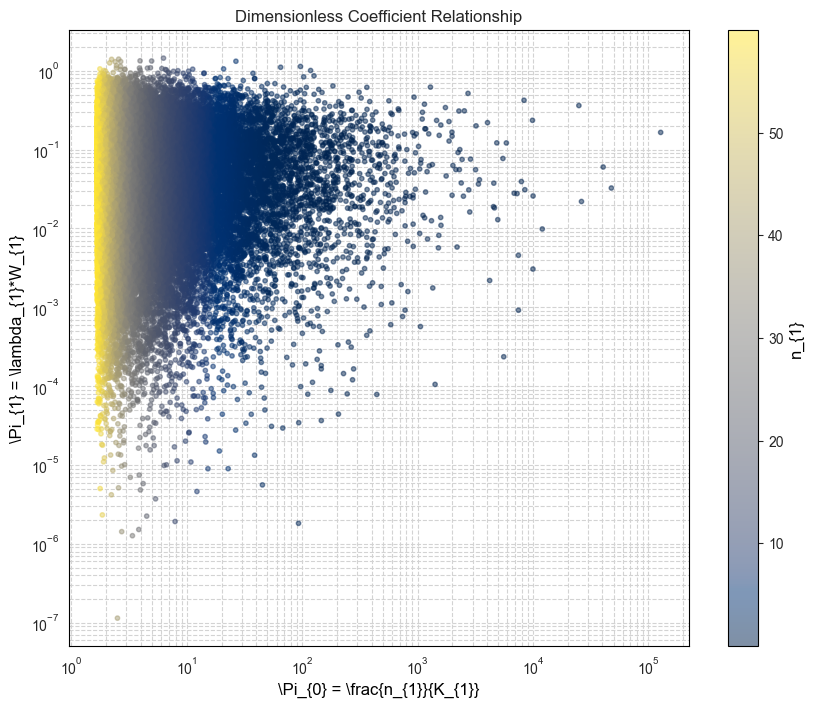

In [20]:
# Create a Moody-like dimensionless plot
# plt.figure(figsize=(10, 8))
plt.figure(figsize=(10, 8), facecolor="white")  # Set figure background to white
ax = plt.gca()
ax.set_facecolor("white") 

# Get first two coefficients for demonstration
pi_list = list(tas_mch._coefficients.keys())
print(pi_list)
pi_x = pi_list[0]  # First coefficient for x-axis
pi_y = pi_list[1]  # Second coefficient for y-axis

# Create scatter plot with color based on a third variable (e.g., third coefficient or input)
scatter = plt.scatter(
    df_results[pi_x],
    df_results[pi_y],
    # Color by one of the variables (adjust as needed)
    c=df_results["n_{1}_\\Pi_{0}"],
    alpha=0.5,
    s=10,
    cmap="cividis"
)

# Add color bar
plt.colorbar(scatter, label="n_{1}")

# Log scales often work well for dimensionless plots
plt.xscale("log")
plt.yscale("log")

# Labels and title
plt.xlabel(f"{pi_x} = {tas_mch._coefficients[pi_x].pi_expr}")
plt.ylabel(f"{pi_y} = {tas_mch._coefficients[pi_y].pi_expr}")
plt.title("Dimensionless Coefficient Relationship")
plt.grid(True, which="both", ls="--", alpha=1)  # Make grid lines more subtle


# # Save the figure
# plt.savefig("data/CS-1-HealthTAS/img/tas_dimensionless_chart.png",
#             dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

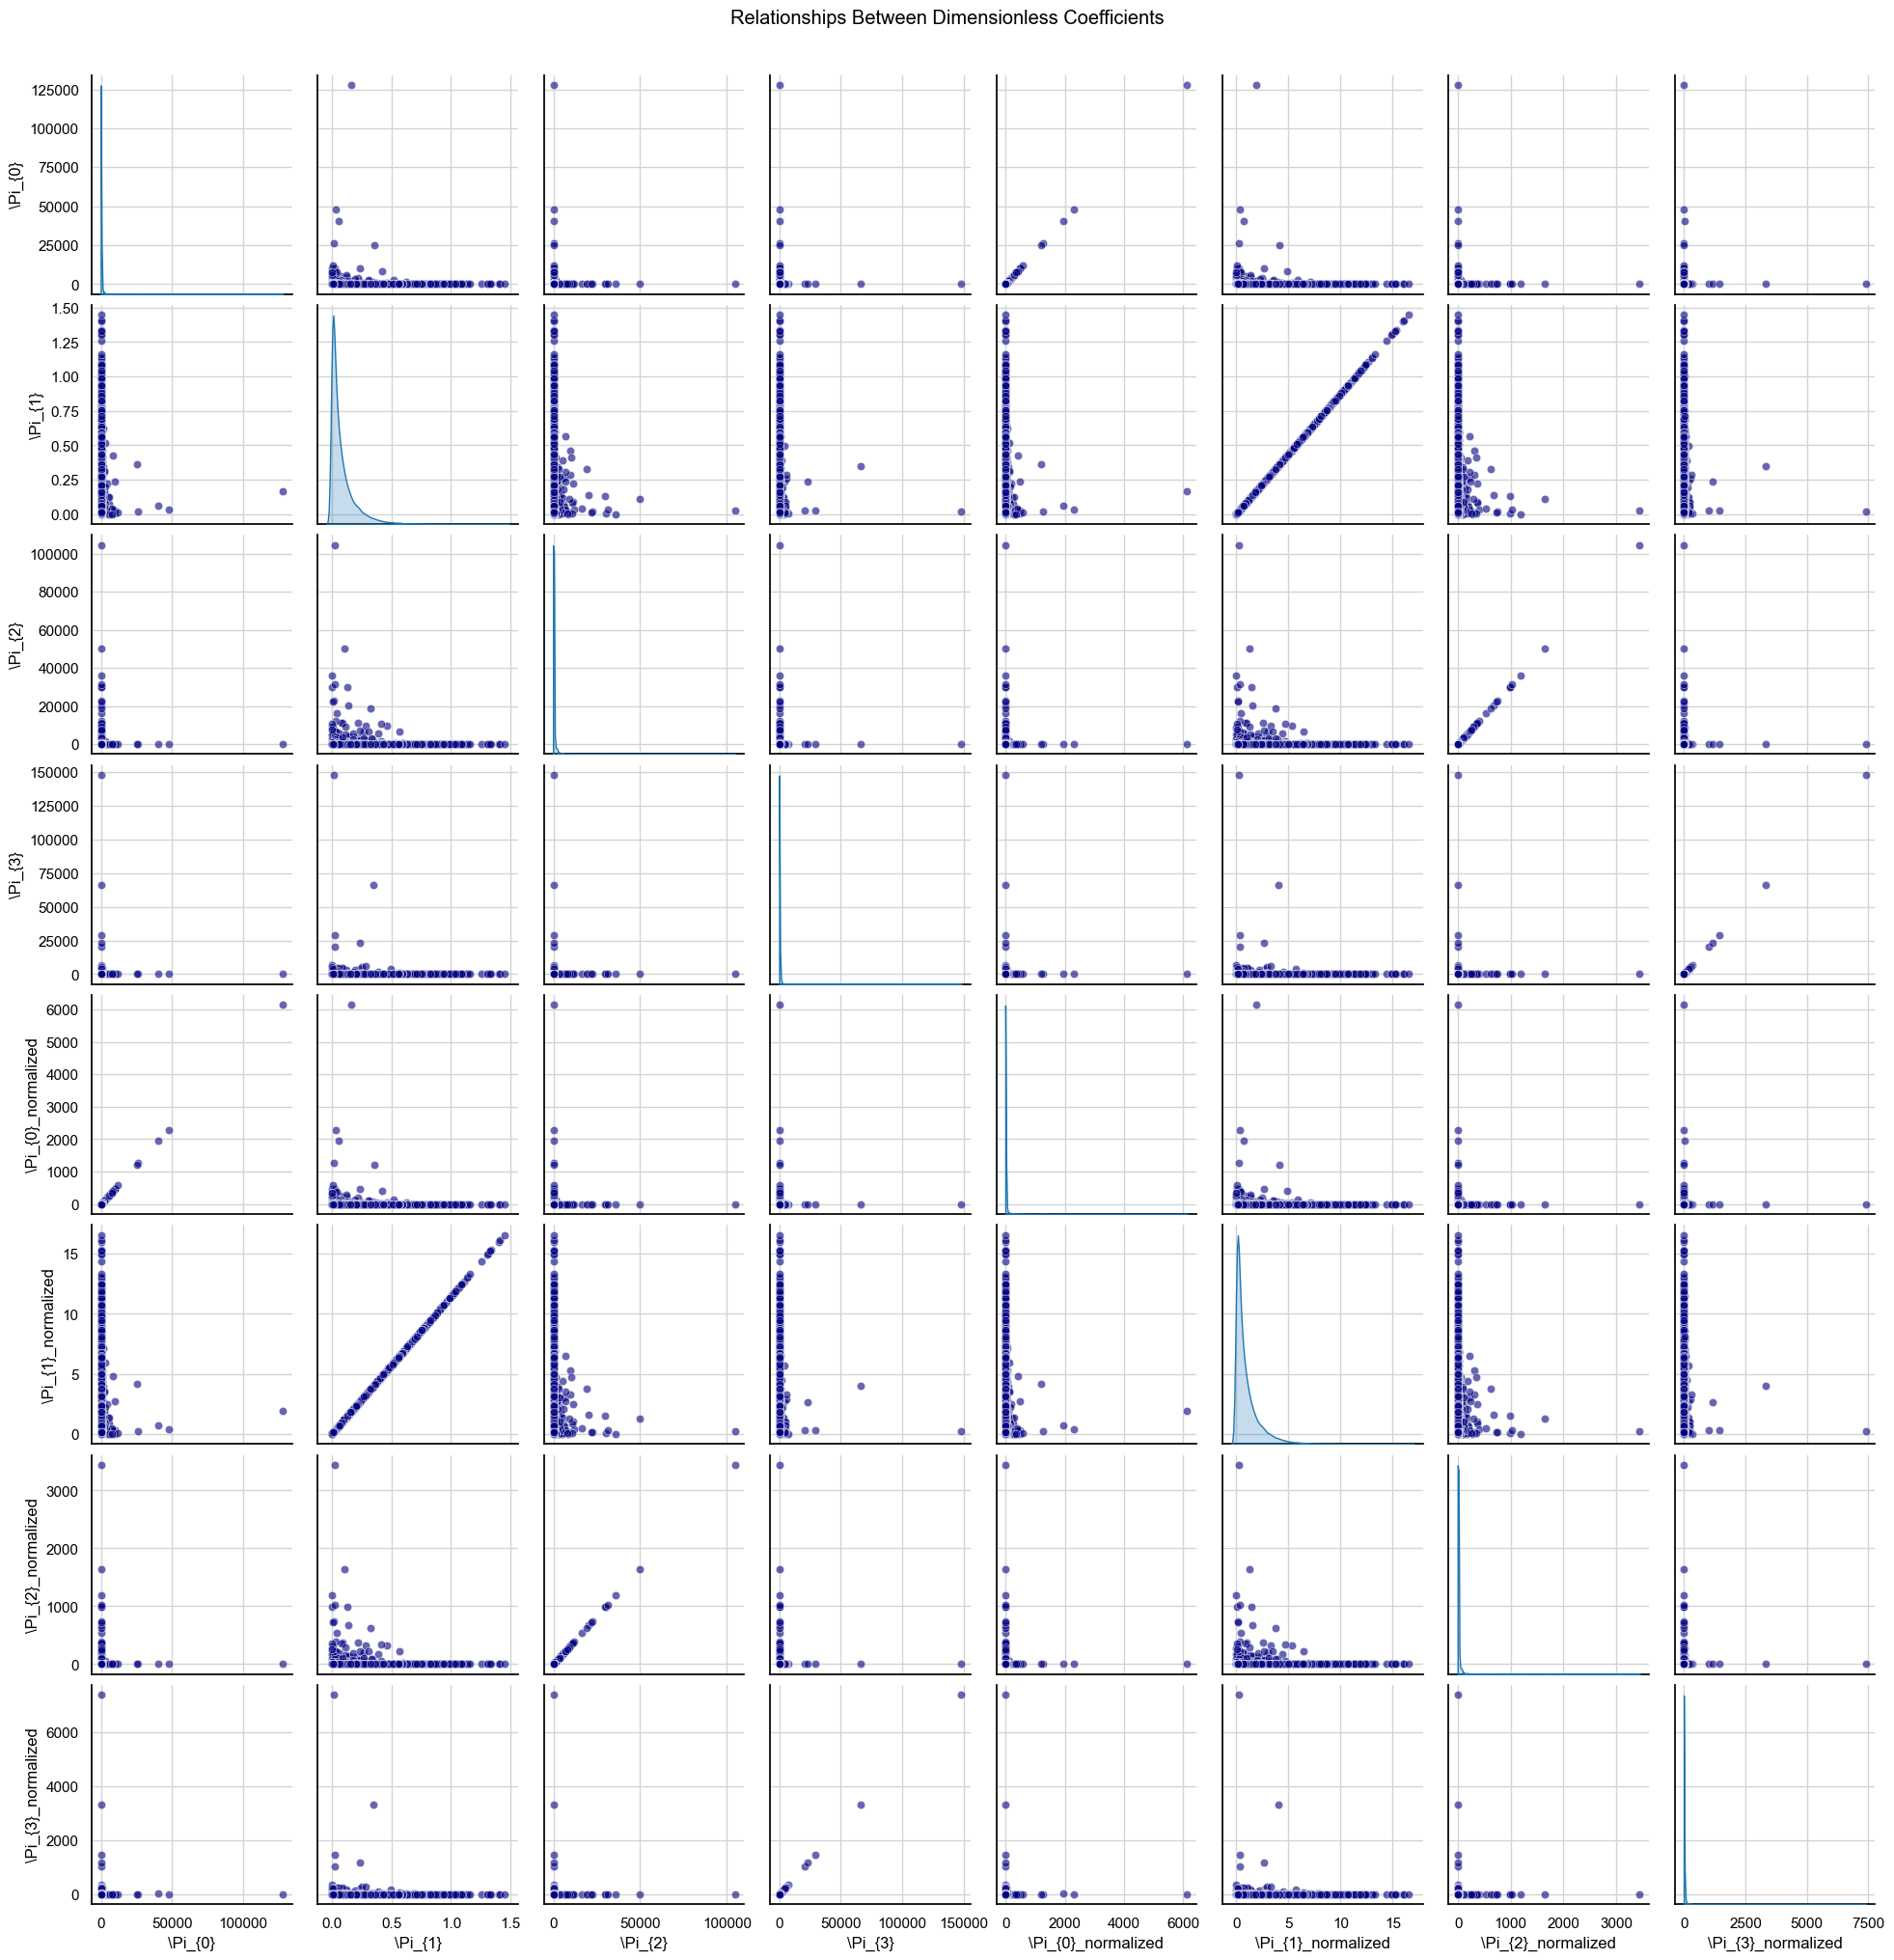

In [21]:
# Create a pairplot with white background and black text
sns.set_context("notebook", font_scale=1.0)

# Create a pairplot to see relationships between multiple coefficients
coef_columns = [col for col in df_results.columns if col.startswith("\\Pi")]
g = sns.pairplot(df_results[coef_columns], diag_kind="kde", height=2.5,
                 plot_kws={'alpha': 0.6, 'color': 'navy'})

# Set white background and black text for all subplots
for ax in g.axes.flatten():
    ax.set_facecolor('white')
    ax.tick_params(colors='black', which='both')
    for text in ax.texts:
        text.set_color('black')

# Set figure background and title
g.fig.patch.set_facecolor('white')
plt.suptitle("Relationships Between Dimensionless Coefficients",
             y=1.02, color='black')

# # Save with white background
# plt.savefig("data/CS-1-HealthTAS/img/tas_coefficient_relationships.png",
#             dpi=500, bbox_inches='tight', facecolor='white')
plt.show()

In [22]:
df_results.columns.tolist()

['n_{1}_\\Pi_{0}',
 'K_{1}_\\Pi_{0}',
 '\\Pi_{0}',
 '\\lambda_{1}_\\Pi_{1}',
 'W_{1}_\\Pi_{1}',
 '\\Pi_{1}',
 '\\miu_{1}_\\Pi_{2}',
 '\\lambda_{1}_\\Pi_{2}',
 '\\Pi_{2}',
 'L_{1}_\\Pi_{3}',
 'K_{1}_\\Pi_{3}',
 '\\Pi_{3}',
 '\\Pi_{0}_normalized',
 '\\Pi_{1}_normalized',
 '\\Pi_{2}_normalized',
 '\\Pi_{3}_normalized']

In [23]:
for k, v in tas_sena.coefficients.items():
    pi = v
    print(f"Coefficient: {k} = {pi._pi_expr}")

Coefficient: \Pi_{0} = \frac{n_{1}}{K_{1}}
Coefficient: \Pi_{1} = \lambda_{1}*W_{1}
Coefficient: \Pi_{2} = \frac{\miu_{1}}{\lambda_{1}}
Coefficient: \Pi_{3} = \frac{L_{1}}{K_{1}}


NOTES:

- $\Pi_{0}$ should be the x-axis.
- $\Pi_{1}$ should be the y-axis.
- $\Pi_{3}$ should be the contour.
- $\Pi_{2}$ should be the color of the lines.

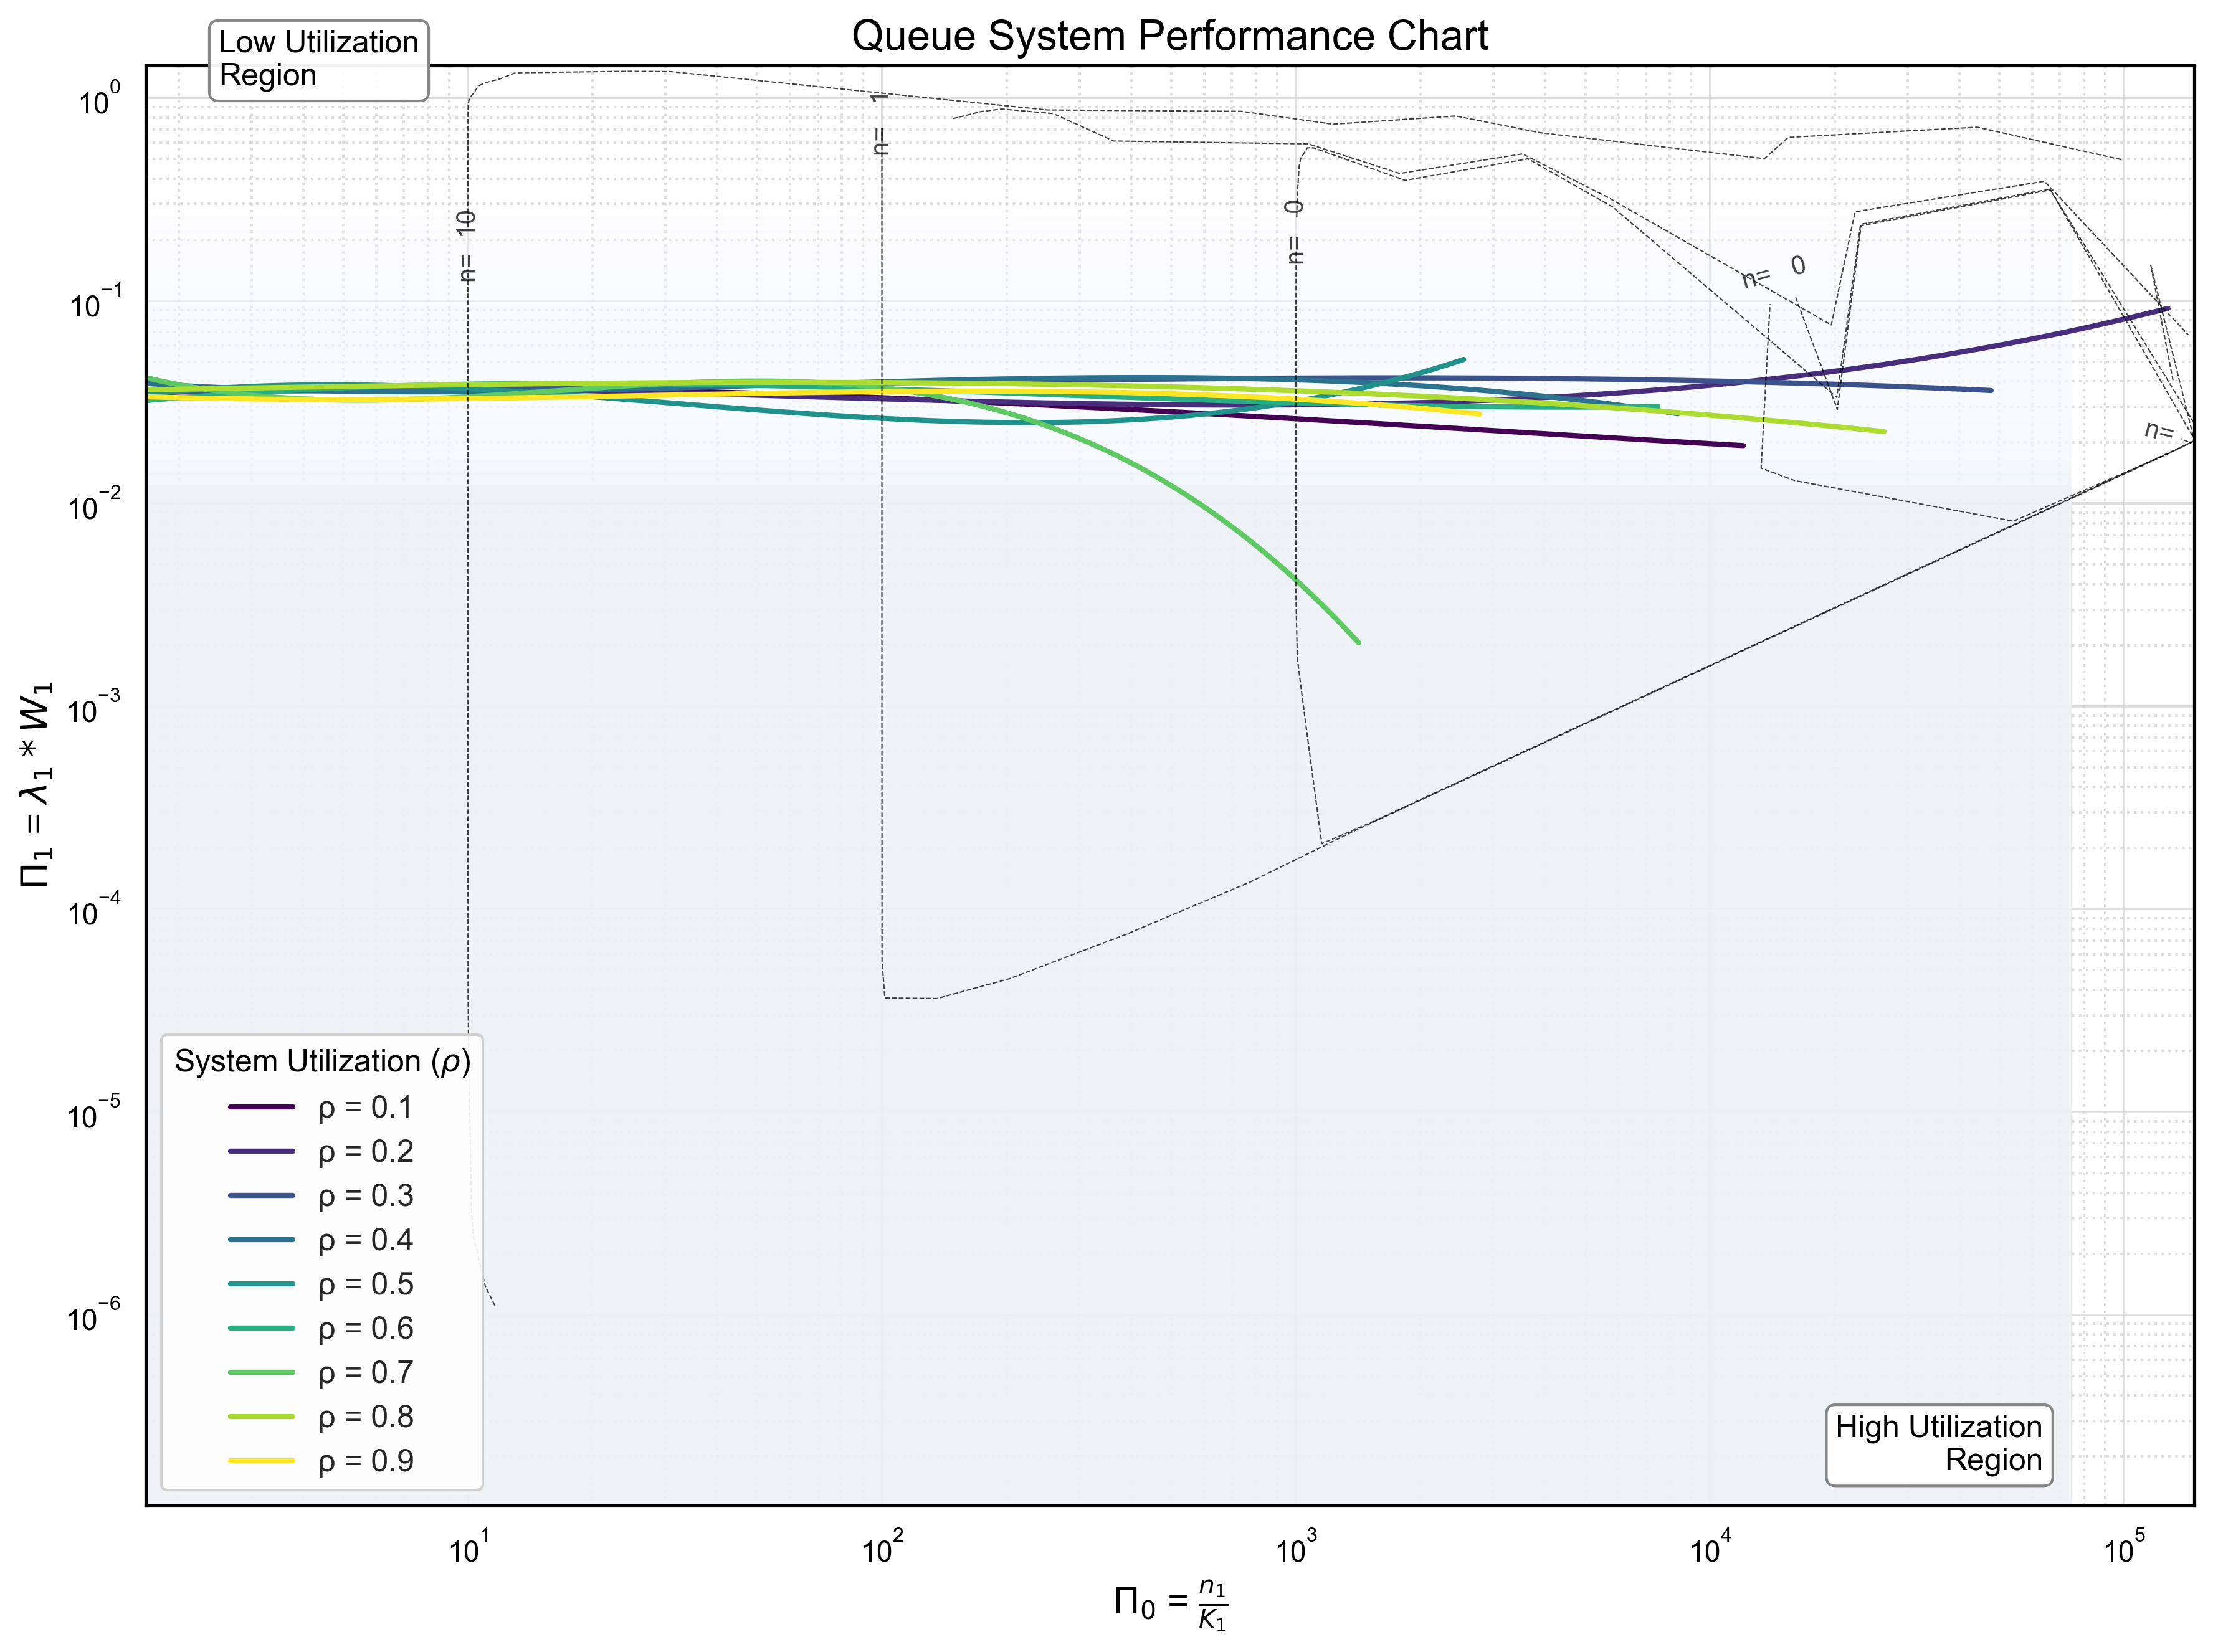

In [24]:
# Create directories if they dont exist
os.makedirs("data/CS-1-HealthTAS/img", exist_ok=True)

# Figure setup with appropriate size, resolution and white background
fig, ax = plt.subplots(figsize=(12, 9), dpi=300, facecolor="white")
ax.set_facecolor("white")

# Get first two coefficients for the plot axes
pi_list = list(tas_mch._coefficients.keys())
pi_x = pi_list[0] # / pi_list[3]  # first/Third coefficient for x-axis
pi_x1 = pi_list[3]               # First coefficient for x-axis
pi_y = pi_list[1]               # Second coefficient for y-axis

# Calculate utilization ratio (common in queueing theory)
df_results["utilization"] = 1 / df_results["\\Pi_{2}"]

# Group data by utilization ratio to create characteristic curves
utilization_ranges = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
colors = plt.cm.viridis(np.linspace(0, 1, len(utilization_ranges)))

# Add hexbin background to show data density (like Moody chart)
hb = plt.hexbin(
    df_results[pi_x],
    df_results[pi_y],
    gridsize=40,
    cmap="Blues",
    alpha=0.10,
    mincnt=1
)

# Plot characteristic curves for different utilization ranges
for i, util in enumerate(utilization_ranges):
    # Filter data near this utilization value
    mask = (df_results["utilization"] >= util - 0.05) & \
           (df_results["utilization"] <= util + 0.05)
    subset = df_results[mask]

    if len(subset) > 10:  # Only draw if we have enough points
        # Sort by x-value for smooth curves
        subset = subset.sort_values(by=pi_x)

        # Create a polynomial fit (3rd degree works well for most curves)
        if len(subset) > 5:
            z = np.polyfit(np.log10(subset[pi_x]), np.log10(subset[pi_y]), 3)
            p = np.poly1d(z)

            # Create smooth x values for the line
            x_smooth = np.logspace(
                np.log10(subset[pi_x].min()),
                np.log10(subset[pi_x].max()),
                100
            )

            # Calculate predicted y values (convert back from log space)
            y_smooth = 10**p(np.log10(x_smooth))

            # Plot the trend line
            plt.plot(
                x_smooth,
                y_smooth,
                "-",
                linewidth=2,
                color=colors[i],
                label=f"ρ = {util:.1f}"
            )

# Add contour lines for queue length
queue_length_values = [1e-3, 1e-2, 1e-1, 1.0, 1e1, 1e2, 1e3]
# [10, 20, 30, 40, 50]
# [1e-3, 1e-2, 1e-1, 1.0, 1e1, 1e2, 1e3]
contour = plt.tricontour(
    df_results[pi_x1],
    df_results[pi_y],
    # df_results["\\Pi_{0}"],
    # df_results["n_{1}_\\Pi_{0}"],
    df_results["L_{1}_\\Pi_{3}"],
    # df_results[pi_x] / df_results[pi_x1],
    levels=queue_length_values,
    colors="black",
    linestyles="dashed",
    linewidths=0.5,
    alpha=0.75
)

# Add contour labels in black
plt.clabel(contour, inline=True, fontsize=10, fmt="n=%4.0f", colors="black")

# Set up log scales (standard for Moody-like charts)
plt.xscale("log")
plt.yscale("log")

# Add grid with minor lines - lighter color for better visibility on white background
plt.grid(True, which="both", ls="-", color="lightgray", alpha=0.75)
plt.grid(True, which="minor", ls=":", color="lightgray", alpha=0.75)
plt.minorticks_on()

# Format tick labels for better readability
formatter = ticker.LogFormatterMathtext(base=10)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Make sure ticks and labels are black
ax.tick_params(axis="both", colors="black")

# Add descriptive labels and title in black
plt.xlabel(
    f"${pi_x}$ = ${tas_mch._coefficients[pi_x].pi_expr}$", fontsize=14, color="black")
plt.ylabel(
    f"${pi_y}$ = ${tas_mch._coefficients[pi_y].pi_expr}$", fontsize=14, color="black")
plt.title("Queue System Performance Chart", fontsize=16, color="black")

# Add legend with clear styling
legend = plt.legend(
    title="System Utilization ($\\rho$)",
    loc="best",
    fontsize=12,
    framealpha=0.9
)
legend.get_title().set_color("black")

# Add annotations for regions with better visibility on white background
plt.text(
    df_results[pi_x].min()*1.5,
    df_results[pi_y].max()*0.8,
    "Low Utilization\nRegion",
    fontsize=12,
    ha="left",
    color="black",
    bbox=dict(facecolor="white", alpha=0.95, boxstyle="round", edgecolor="gray")
)

plt.text(
    df_results[pi_x].max()*0.5,
    df_results[pi_y].min()*1.5,
    "High Utilization\nRegion",
    fontsize=12,
    ha="right",
    color="black",
    bbox=dict(facecolor="white", alpha=0.95, boxstyle="round", edgecolor="gray")
)

# Save and display with white background
plt.tight_layout()
plt.savefig("data/CS-1-HealthTAS/img/tas_behaviour_chart.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### **Arternative Design No.1 (Horizontal Scaling)**

#### **Dimensional Variables**

#### **Dimensionless Coefficients**

#### **Sensitivity Analysis**

#### **Monte Carlo Simulation**

### **Arternative Design No.2 (Vertical Scaling)**

#### **Dimensional Variables**

#### **Dimensionless Coefficients**

#### **Sensitivity Analysis**

#### **Monte Carlo Simulation**

## **Conclusion**

## **Future Work**